# Resolução — S03-01

Notebook em **Julia**, corrigido para atender aos requisitos pedido pelo professor 
Prof. Kenny Vinente dos Santos, Dr. | kennyvinente@ufam.edu.br
# Nome: Renyer Montefusco levy
# Matrícula: 2240917

Inclui:
- cálculo do machine epsilon;
- Método de Newton para uma variável;
- gráfico de iterações × F(x);
- Método de Newton para sistemas não lineares;
- testes com diferentes pontos iniciais.


## Pacotes utilizados

In [1]:
using LinearAlgebra
using Printf

# Pacote usado para gerar o gráfico solicitado.
# Caso não tenha instalado, execute uma vez:
# using Pkg
# Pkg.add("Plots")

using Plots

## Machine epsilon

O objetivo é encontrar o menor número positivo `epsilon` tal que o computador ainda consiga distinguir `1 + epsilon` de `1`.


In [2]:
epsilon = 1.0

while 1.0 + epsilon/2.0 > 1.0
    global epsilon = epsilon / 2.0
end

println("Machine epsilon = ", epsilon)

Machine epsilon = 2.220446049250313e-16


# Método de Newton — Uma variável

A fórmula é:

\[
x_{k+1}=x_k-\frac{F(x_k)}{F'(x_k)}
\]


In [3]:
function newton_scalar(F, dF, x0; eps=1e-15, maxiter=100)
    x = float(x0)
    historico = []

    for k in 0:maxiter
        fx = F(x)
        push!(historico, (Iteracao=k, x=x, Fx=fx))

        if abs(fx) < eps
            break
        end

        dfx = dF(x)

        if abs(dfx) < eps
            println("Derivada muito próxima de zero. O método foi interrompido.")
            break
        end

        x = x - fx/dfx
    end

    return x, historico
end

function mostrar_historico_scalar(historico)
    println("Iteração | x | F(x)")
    println("------------------------------------------")
    for linha in historico
        @printf("%8d | %.16f | %.16e\n", linha.Iteracao, linha.x, linha.Fx)
    end
end

mostrar_historico_scalar (generic function with 1 method)

## Exemplo 1

\[
F(x)=x^2-2
\]

com \(x_0=2\) e \(\varepsilon=10^{-15}\).


In [4]:
F(x) = x^2 - 2
dF(x) = 2x

raiz, historico = newton_scalar(F, dF, 2.0)

mostrar_historico_scalar(historico)

println()
println("Raiz aproximada = ", raiz)
println("Erro = ", abs(F(raiz)))

Iteração | x | F(x)
------------------------------------------
       0 | 2.0000000000000000 | 2.0000000000000000e+00
       1 | 1.5000000000000000 | 2.5000000000000000e-01
       2 | 1.4166666666666667 | 6.9444444444446418e-03
       3 | 1.4142156862745099 | 6.0073048828712672e-06
       4 | 1.4142135623746899 | 4.5106141044470860e-12
       5 | 1.4142135623730951 | 4.4408920985006262e-16

Raiz aproximada = 1.4142135623730951
Erro = 4.440892098500626e-16


### Gráfico solicitado: iterações × valor de \(F(x)\)

Este gráfico atende ao item pedido no arquivo original do professor.


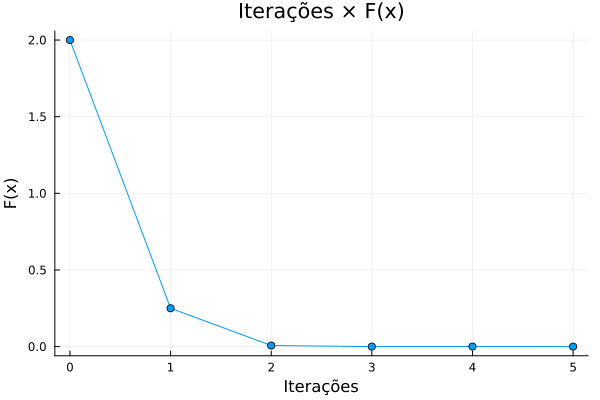

In [5]:
iteracoes = [linha.Iteracao for linha in historico]
valores_Fx = [linha.Fx for linha in historico]

plot(
    iteracoes,
    valores_Fx,
    marker=:circle,
    xlabel="Iterações",
    ylabel="F(x)",
    title="Iterações × F(x)",
    legend=false
)

## Exemplo 2

\[
F(x)=x-\sin(x)
\]

com \(x_0=1\) e \(\varepsilon=10^{-15}\).


In [6]:
F(x) = x - sin(x)
dF(x) = 1 - cos(x)

raiz, historico = newton_scalar(F, dF, 1.0)

mostrar_historico_scalar(historico)

println()
println("Raiz aproximada = ", raiz)
println("Erro = ", abs(F(raiz)))

Iteração | x | F(x)
------------------------------------------
       0 | 1.0000000000000000 | 1.5852901519210350e-01
       1 | 0.6551450720424304 | 4.5870786040895783e-02
       2 | 0.4335903683634927 | 1.3458737959401001e-02
       3 | 0.2881484008925012 | 3.9709484604172895e-03
       4 | 0.1918323121506386 | 1.1743969232932971e-03
       5 | 0.1278096675607083 | 3.4768434920498525e-04
       6 | 0.0851832336028641 | 1.0298015675494487e-04
       7 | 0.0567819527866164 | 3.0507717045380467e-05
       8 | 0.0378526007811133 | 9.0386758038185633e-06
       9 | 0.0252344645350151 | 2.6780408849888526e-06
      10 | 0.0168227978108712 | 7.9348236674617323e-07
      11 | 0.0112151456404626 | 2.3510440783081066e-07
      12 | 0.0074767480865235 | 6.9660370574306518e-08
      13 | 0.0049844940803019 | 2.0640084159168071e-08
      14 | 0.0033229946775364 | 6.1155771150303573e-09
      15 | 0.0022153293773367 | 1.8120224045195532e-09
      16 | 0.0014768861306941 | 5.3689546862176196e-10
  

## Exemplo 3

\[
F(x)=\arctan(x)
\]

com \(x_0=1.5\), \(\varepsilon=10^{-15}\) e `maxiter = 10`.


In [7]:
F(x) = atan(x)
dF(x) = 1/(1+x^2)

raiz, historico = newton_scalar(F, dF, 1.5; maxiter=10)

mostrar_historico_scalar(historico)

println()
println("Resultado aproximado = ", raiz)
println("Erro = ", abs(F(raiz)))

Derivada muito próxima de zero. O método foi interrompido.
Iteração | x | F(x)
------------------------------------------
       0 | 1.5000000000000000 | 9.8279372324732905e-01
       1 | -1.6940796005538195 | -1.0375463591378908e+00
       2 | 2.3211269614383880 | 1.1640020424219752e+00
       3 | -5.1140878367775136 | -1.3776945287027522e+00
       4 | 32.2956839142100165 | 1.5398423269080117e+00
       5 | -1575.3169508212042729 | -1.5701615339900847e+00
       6 | 3894976.0077608842402697 | 1.5707960700539056e+00
       7 | -23830288973552.1250000000000000 | -1.5707963267948546e+00

Resultado aproximado = -2.3830288973552125e13
Erro = 1.5707963267948546


# Método de Newton para sistemas não lineares

Para sistemas, usamos:

\[
J(x_k)\Delta x=-F(x_k)
\]

e depois:

\[
x_{k+1}=x_k+\Delta x
\]


In [8]:
function newton_system(F, J, x0; eps=1e-15, maxiter=100)
    x = float.(x0)
    historico = []

    for k in 0:maxiter
        Fx = F(x)
        norma = norm(Fx)

        push!(historico, (Iteracao=k, x=copy(x), Norma=norma))

        if norma < eps
            break
        end

        delta = J(x) \ (-Fx)
        x = x + delta
    end

    return x, historico
end

function mostrar_historico_sistema(historico)
    println("Iteração | x | ||F(x)||")
    println("-----------------------------------------------------")
    for linha in historico
        @printf("%8d | [% .16f, % .16f] | %.16e\n",
            linha.Iteracao,
            linha.x[1],
            linha.x[2],
            linha.Norma
        )
    end
end

mostrar_historico_sistema (generic function with 1 method)

## Sistema 1

\[
F(x)=
\begin{bmatrix}
(x_1+1)^2+x_2^2-2 \\
e^{x_1}+x_2^3-2
\end{bmatrix}
\]

com:

\[
x_0=
\begin{bmatrix}
1 \\
1
\end{bmatrix}
\]


In [9]:
function F1(x)
    x1 = x[1]
    x2 = x[2]

    return [
        (x1 + 1)^2 + x2^2 - 2,
        exp(x1) + x2^3 - 2
    ]
end

function J1(x)
    x1 = x[1]
    x2 = x[2]

    return [
        2*(x1 + 1)  2*x2;
        exp(x1)     3*x2^2
    ]
end

solucao, historico = newton_system(F1, J1, [1.0, 1.0])

mostrar_historico_sistema(historico)

println()
println("Solução = ", solucao)
println("Norma do erro = ", norm(F1(solucao)))

Iteração | x | ||F(x)||
-----------------------------------------------------
       0 | [ 1.0000000000000000,  1.0000000000000000] | 3.4572376895453050e+00
       1 | [ 0.1523592136387572,  1.1952815727224857] | 1.1547087094487691e+00
       2 | [-0.0108376809361459,  1.0361111672588803] | 1.1404255764776242e-01
       3 | [-0.0008896646014697,  1.0015353164941012] | 3.9423297592256906e-03
       4 | [-0.0000013700887511,  1.0000029387079050] | 8.0799855602939694e-06
       5 | [-0.0000000000055385,  1.0000000000107949] | 2.8831122569542358e-11
       6 | [-0.0000000000000001,  1.0000000000000002] | 4.4408920985006262e-16

Solução = [-1.0463793574265223e-16, 1.0000000000000002]
Norma do erro = 4.440892098500626e-16


## Sistema 2

\[
F(x)=
\begin{bmatrix}
x_1^3 - 3x_1x_2^2 -1 \\
x_2^3 - 3x_1^2x_2
\end{bmatrix}
\]

com:

\[
x_0=
\begin{bmatrix}
1 \\
1
\end{bmatrix}
\]


In [10]:
function F2(x)
    x1 = x[1]
    x2 = x[2]

    return [
        x1^3 - 3*x1*x2^2 - 1,
        x2^3 - 3*x1^2*x2
    ]
end

function J2(x)
    x1 = x[1]
    x2 = x[2]

    return [
        3*x1^2 - 3*x2^2   -6*x1*x2;
        -6*x1*x2           3*x2^2 - 3*x1^2
    ]
end

solucao, historico = newton_system(F2, J2, [1.0, 1.0])

mostrar_historico_sistema(historico)

println()
println("Solução = ", solucao)
println("Norma do erro = ", norm(F2(solucao)))

Iteração | x | ||F(x)||
-----------------------------------------------------
       0 | [ 1.0000000000000000,  1.0000000000000000] | 3.6055512754639891e+00
       1 | [ 0.6666666666666667,  0.5000000000000000] | 1.3199641601527641e+00
       2 | [ 0.5788444444444445, -0.1274666666666667] | 8.4373632058578907e-01
       3 | [ 1.2469639815750162,  0.3135784251549973] | 1.5416110765932423e+00
       4 | [ 1.0089481977515047,  0.1136779651549011] | 3.4590469074990021e-01
       5 | [ 0.9878680459783756,  0.0038368436428647] | 3.7711505056585486e-02
       6 | [ 1.0001341442102127, -0.0000953221850963] | 4.9375529428494290e-04
       7 | [ 1.0000000089100061, -0.0000000255681329] | 8.1228435715603736e-08
       8 | [ 0.9999999999999994, -0.0000000000000005] | 2.1544562865794244e-15
       9 | [ 1.0000000000000000,  0.0000000000000000] | 1.4791141972893971e-30

Solução = [1.0, 4.930380657631324e-31]
Norma do erro = 1.4791141972893971e-30


## Sistema 2 — novo ponto inicial

\[
x_0=
\begin{bmatrix}
-1 \\
-1
\end{bmatrix}
\]


In [11]:
solucao, historico = newton_system(F2, J2, [-1.0, -1.0])

mostrar_historico_sistema(historico)

println()
println("Solução = ", solucao)
println("Norma do erro = ", norm(F2(solucao)))

Iteração | x | ||F(x)||
-----------------------------------------------------
       0 | [-1.0000000000000000, -1.0000000000000000] | 2.2360679774997898e+00
       1 | [-0.6666666666666667, -0.8333333333333334] | 5.4039895971892382e-01
       2 | [-0.5086919161874546, -0.8410998744133783] | 7.7840426359683537e-02
       3 | [-0.4993299956437513, -0.8662691717880057] | 2.1386503574991130e-03
       4 | [-0.4999999113699129, -0.8660249031568892] | 1.5252366691137052e-06
       5 | [-0.4999999999999554, -0.8660254037846932] | 7.7529900908774050e-13
       6 | [-0.4999999999999999, -0.8660254037844386] | 2.4825341532472731e-16

Solução = [-0.49999999999999994, -0.8660254037844386]
Norma do erro = 2.482534153247273e-16


## Sistema 2 — terceiro ponto inicial

\[
x_0=
\begin{bmatrix}
0 \\
1
\end{bmatrix}
\]


In [12]:
solucao, historico = newton_system(F2, J2, [0.0, 1.0])

mostrar_historico_sistema(historico)

println()
println("Solução = ", solucao)
println("Norma do erro = ", norm(F2(solucao)))

Iteração | x | ||F(x)||
-----------------------------------------------------
       0 | [ 0.0000000000000000,  1.0000000000000000] | 1.4142135623730951e+00
       1 | [-0.3333333333333333,  0.6666666666666667] | 5.9720427765174444e-01
       2 | [-0.5822222222222222,  0.9244444444444444] | 3.3128125366359484e-01
       3 | [-0.5087908032893191,  0.8681655118873491] | 2.7312827580817479e-02
       4 | [-0.5000687390673927,  0.8659822186925401] | 2.4353592068521168e-04
       5 | [-0.4999999962890297,  0.8660253983385868] | 1.9770114366873654e-08
       6 | [-0.5000000000000001,  0.8660254037844387] | 4.9650683064945462e-16

Solução = [-0.5000000000000001, 0.8660254037844387]
Norma do erro = 4.965068306494546e-16
